In [2]:
import os
import sys
import glob
import numpy as np
from tqdm import trange
from astropy.io import fits
from astropy.table import Table, vstack
from astropy.convolution import convolve, Gaussian1DKernel
import astropy.units as u
import astropy.coordinates as coord
import matplotlib
import matplotlib.pyplot as plt
from astropy.table import Column
from tqdm import trange
import pandas as pd
import fitsio
from astropy.table import Table, vstack
from astropy import units as u
from astropy.coordinates import SkyCoord
from easyquery import Query, QueryMaker
from scipy.stats import binomtest
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm
from matplotlib.colors import ListedColormap, BoundaryNorm
import h5py
from astropy.cosmology import Planck18



mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

rootdir = '/global/u1/v/virajvm/'
sys.path.append(os.path.join(rootdir, 'DESI2_LOWZ/desi_dwarfs/code'))

from desi_lowz_funcs import make_subplots, match_c_to_catalog, print_radecs
from desi_lowz_funcs import calc_normalized_dist
from desi_lowz_funcs import find_objects_nearby

from independent_distances import parse_mei2007, MEI_SBF_FILE, COTE_RADEC_FILE, parse_cote2004, update_distance_catalog


%load_ext autoreload
%autoreload 2


In [7]:
# Path to the catalog
filename = "/pscratch/sd/v/virajvm/desi_dwarf_catalogs/dr1/v1.0/desi_dr1_dwarf_catalog.fits"

# Option 1: load the MAIN extension directly as an Astropy Table
tot_cat = Table.read(filename, hdu="MAIN")

tot_cat = tot_cat[tot_cat["DWARF_PRIMARY"] == True]

print(len(tot_cat))

379054


In [148]:
# parse_cote2004(COTE_RADEC_FILE)["RA","DEC"]

In [147]:
# parse_mei2007(MEI_SBF_FILE)

In [65]:
tot_cat_new, ned_cat, mei_with_coords, evcc_tab = update_distance_catalog(keep_lumi_dist_orig=True)

Loading DESI dwarf catalog...
  Loaded 381740 galaxies

Step 1: Cross-matching with NED LVS zIndependent distances...
  NED LVS full catalog: 2103732 entries
  After filtering (zIndependent, ziDist>3, indicator=P): 387 entries
  Matched 27 galaxies within their R50_R of a NED LVS source
  Separation stats: median=4.04", max=56.27"

Step 2: Cross-matching remaining galaxies with Mei et al. 2007 SBF distances...
[Mei et al. 2007] Parsed 84 galaxies with SBF distances
[Cote et al. 2004] Parsed 100 galaxies with RA/Dec
  Mei+Cote merged table: 84 galaxies with SBF dist + RA/Dec
  Matched 4 galaxies within their R50_R of a Mei et al. source
  Separation stats: median=0.44", max=0.59"
  Distance range: 15.78 - 17.78 Mpc

Step 3: Cross-matching remaining galaxies with EVCC (Kim et al. 2014)...
[Kim et al. 2014 EVCC] Total galaxies in catalog: 1589
[Kim et al. 2014 EVCC] Kept 1064 certain members (MemIn=M: 1028, MemVCC=M: 631)
  Matched 148 galaxies within their R50_R of an EVCC member
  Separ

In [58]:
np.unique(tot_cat_new["DIST_SOURCE"])

CF3_NAM
NED_ZIND
VIRGO_EVCC
VIRGO_SBF
V_CMB


In [129]:
from desi_lowz_funcs import make_alternating_plot


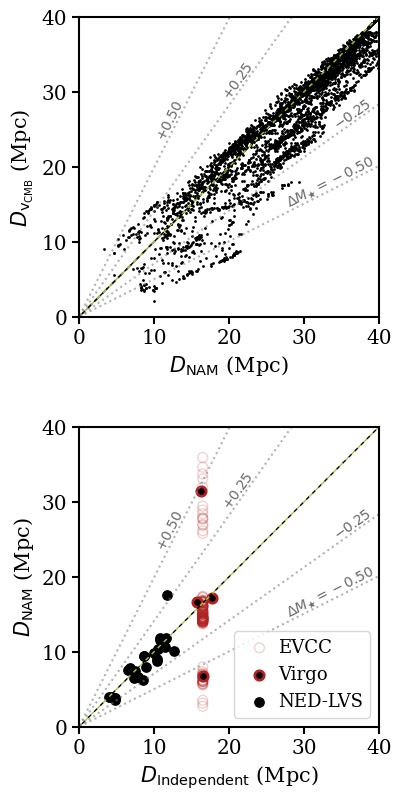

In [143]:
##where we do have independant measurements, we want to compuare it with that

ned_mask = (tot_cat_new["DIST_SOURCE"] == "NED_ZIND")
virgo_sbf_mask = (tot_cat_new["DIST_SOURCE"] == "VIRGO_SBF")
virgo_evcc_mask = (tot_cat_new["DIST_SOURCE"] == "VIRGO_EVCC")

CF3_NAM_mask = (tot_cat_new["DIST_SOURCE"] == "CF3_NAM")


fig,ax = make_subplots(ncol=1,nrow=2,return_fig=True)

ax[0].scatter( tot_cat_new["LUMI_DIST_MPC"].data[virgo_evcc_mask], tot_cat_new["LUMI_DIST_ORIG"].data[virgo_evcc_mask],  
              label = "EVCC", edgecolor="firebrick",s=50,facecolor="none",alpha=0.2)

ax[0].scatter(  tot_cat_new["LUMI_DIST_MPC"].data[virgo_sbf_mask], tot_cat_new["LUMI_DIST_ORIG"].data[virgo_sbf_mask],
              label = "Virgo", facecolor= "k",s=45,edgecolor="firebrick",lw=2)

ax[0].scatter( tot_cat_new["LUMI_DIST_MPC"].data[ned_mask], tot_cat_new["LUMI_DIST_ORIG"].data[ned_mask],  
              label = "NED-LVS", color="k",s=45)


ax[0].legend(frameon=True,fontsize = 13,loc="lower right",handletextpad=0.01)


ax[0].set_ylabel(r"$D_{\rm NAM}$ (Mpc)",fontsize = 15)

ax[0].set_xlabel(r"$D_{\rm Independent}$ (Mpc)",fontsize = 15)


#############################

#for all the objects just plot their Z_CMB based luminosity distance
lumi_dist_cmb = Planck18.luminosity_distance(tot_cat_new["Z_CMB"][CF3_NAM_mask]).data

#this is theoriginal distrance!
ax[1].scatter( lumi_dist_cmb, tot_cat_new["LUMI_DIST_ORIG"][CF3_NAM_mask],s=1,color="k")

ax[1].set_xlabel(r"$D_{\rm NAM}$ (Mpc)",fontsize = 15)

ax[1].set_ylabel(r"$D_{\rm v_{CMB}}$ (Mpc)",fontsize = 15)

ax[1].set_xlim([0,40])
ax[1].set_ylim([0,40])


ax[1].plot( [0,40], [0,40], color="k",ls="--",alpha=0.5)

for axi in ax:
    axi.set_xlim([0,40])
    axi.set_ylim([0,40])

    #make this the laternatiing plot!!
    xgrid =  np.linspace(0,40,100)
    make_alternating_plot(axi,xgrid,xgrid,dash_len=1,color_1="yellowgreen",color_2="k",lw=1)
    # axi.plot( [0,40], [0,40], color="k",ls="--",alpha=0.5)

fig.canvas.draw()  # Force render so transData is correct

for ax_ind,axi in enumerate(ax):
    d_other = np.linspace(0.1, 40, 200)
    for delta_mstar, x_label in zip([0.5, 0.25, -0.25, -0.5], [13,22,37,34]):
        ratio = 10**(delta_mstar / 1.675)
        d_nam = d_other * ratio
        axi.plot(d_other, d_nam, ls="dotted", color="gray", alpha=0.6)
        
        # Place label along the line
        # Choose x position for the label (adjust to taste)
        # x_label = 15 if delta_mstar > 0 else 30
        y_label = x_label * ratio
        
        # Skip if label would be outside the plot
        if y_label > 40 or y_label < 0:
            x_label = (38 / ratio) if delta_mstar > 0 else 35
            y_label = x_label * ratio
        
        # Compute rotation angle in display coordinates
        # Transform two points on the line to display coords
    
        p1 = axi.transData.transform((x_label - 1, (x_label - 1) * ratio))
        p2 = axi.transData.transform((x_label + 1, (x_label + 1) * ratio))
        angle = np.degrees(np.arctan2(p2[1] - p1[1], p2[0] - p1[0]))


        if delta_mstar == -0.5:
            label = rf"$\Delta M_{{\bigstar}} = {delta_mstar:+.2f}$"
        else:
            label = rf"${delta_mstar:+.2f}$"
            
        
        axi.text(x_label, y_label, label, fontsize=10, color="dimgrey",
                   ha="center", va="bottom", rotation=angle, rotation_mode="anchor")
    

plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/distance_comparison.pdf",bbox_inches="tight")

plt.show()

In [ ]:
0.4*5*np.log10(30) - 0.4*5*np.log10(16.5)

In [87]:
0.4*5*np.log10(5) - 0.4*5*np.log10(16.5)

-1.0370278797557748

In [121]:
## I also want to convey a plot of NAM distances vs. redshift based

In [74]:
def check_ned_virgo_overlap(ned_cat, mei_with_coords, evcc_tab, match_radius_arcsec=5.0):
    """
    Check if any NED LVS sources (with our cuts applied) also appear in
    the Mei et al. 2007 SBF catalog or the EVCC catalog.

    This helps identify cases where the NED redshift-independent distance
    might differ from the Virgo distance assignment (SBF or 16.5 Mpc).

    Parameters
    ----------
    ned_cat : astropy.table.Table
        NED LVS catalog after filtering (zIndependent, ziDist>3, indicator=P).
    mei_with_coords : astropy.table.Table
        Mei et al. 2007 SBF distances merged with Cote et al. 2004 RA/Dec.
        Must have columns: RA, DEC, dist_mpc, VCC.
    evcc_tab : astropy.table.Table
        EVCC catalog (certain members only).
        Must have columns: RA, DEC, EVCC, MemIn, MemVCC.
    match_radius_arcsec : float
        Cross-match radius in arcsec (default: 5.0).

    Returns
    -------
    ned_mei_overlap : astropy.table.Table
        NED sources that match a Mei et al. SBF source, with columns from both.
    ned_evcc_overlap : astropy.table.Table
        NED sources that match an EVCC member, with columns from both.
    """
    ned_coords = SkyCoord(ra=ned_cat['ra'] * u.deg, dec=ned_cat['dec'] * u.deg)

    # -----------------------------------------------------------------
    # 1. NED LVS vs Mei et al. 2007 SBF
    # -----------------------------------------------------------------
    mei_coords = SkyCoord(ra=mei_with_coords['RA'] * u.deg,
                          dec=mei_with_coords['DEC'] * u.deg)

    idx_mei, sep_mei, _ = ned_coords.match_to_catalog_sky(mei_coords)
    mask_mei = sep_mei.arcsec < match_radius_arcsec

    n_mei = np.sum(mask_mei)
    print("=" * 70)
    print(f"NED LVS ↔ Mei et al. 2007 SBF overlap (within {match_radius_arcsec}\")")
    print(f"  {n_mei} NED sources have a Mei et al. SBF match")

    ned_mei_overlap = Table()
    if n_mei > 0:
        ned_mei_overlap['NED_RA'] = ned_cat['ra'][mask_mei]
        ned_mei_overlap['NED_DEC'] = ned_cat['dec'][mask_mei]
        ned_mei_overlap['NED_OBJNAME'] = ned_cat['objname'][mask_mei]
        ned_mei_overlap['NED_ziDist_Mpc'] = ned_cat['ziDist'][mask_mei]
        ned_mei_overlap['MEI_VCC'] = mei_with_coords['VCC'][idx_mei[mask_mei]]
        ned_mei_overlap['MEI_dist_Mpc'] = mei_with_coords['dist_mpc'][idx_mei[mask_mei]]
        ned_mei_overlap['sep_arcsec'] = sep_mei[mask_mei].arcsec
        ned_mei_overlap['dist_diff_Mpc'] = (ned_mei_overlap['NED_ziDist_Mpc']
                                            - ned_mei_overlap['MEI_dist_Mpc'])

        print(f"\n  {'NED_ziDist':>12s} {'MEI_SBF':>10s} {'Diff':>10s} {'Sep':>8s}  VCC")
        print(f"  {'(Mpc)':>12s} {'(Mpc)':>10s} {'(Mpc)':>10s} {'(arcsec)':>8s}")
        print("  " + "-" * 56)
        for row in ned_mei_overlap:
            print(f"  {row['NED_ziDist_Mpc']:12.2f} {row['MEI_dist_Mpc']:10.2f} "
                  f"{row['dist_diff_Mpc']:+10.2f} {row['sep_arcsec']:8.2f}  "
                  f"VCC {row['MEI_VCC']}")

        diffs = ned_mei_overlap['dist_diff_Mpc']
        print(f"\n  Distance difference stats:")
        print(f"    Mean:   {np.mean(diffs):+.2f} Mpc")
        print(f"    Median: {np.median(diffs):+.2f} Mpc")
        print(f"    Std:    {np.std(diffs):.2f} Mpc")
        print(f"    Range:  [{np.min(diffs):+.2f}, {np.max(diffs):+.2f}] Mpc")

    # -----------------------------------------------------------------
    # 2. NED LVS vs EVCC
    # -----------------------------------------------------------------
    evcc_coords = SkyCoord(ra=evcc_tab['RA'] * u.deg,
                           dec=evcc_tab['DEC'] * u.deg)

    idx_evcc, sep_evcc, _ = ned_coords.match_to_catalog_sky(evcc_coords)
    mask_evcc = sep_evcc.arcsec < match_radius_arcsec

    n_evcc = np.sum(mask_evcc)
    print("\n" + "=" * 70)
    print(f"NED LVS ↔ EVCC overlap (within {match_radius_arcsec}\")")
    print(f"  {n_evcc} NED sources have an EVCC match")

    VIRGO_DEFAULT_DIST_MPC = 16.5

    ned_evcc_overlap = Table()
    if n_evcc > 0:
        ned_evcc_overlap['NED_RA'] = ned_cat['ra'][mask_evcc]
        ned_evcc_overlap['NED_DEC'] = ned_cat['dec'][mask_evcc]
        ned_evcc_overlap['NED_OBJNAME'] = ned_cat['objname'][mask_evcc]
        ned_evcc_overlap['NED_ziDist_Mpc'] = ned_cat['ziDist'][mask_evcc]
        ned_evcc_overlap['EVCC_ID'] = evcc_tab['EVCC'][idx_evcc[mask_evcc]]
        ned_evcc_overlap['EVCC_MemIn'] = evcc_tab['MemIn'][idx_evcc[mask_evcc]]
        ned_evcc_overlap['EVCC_MemVCC'] = evcc_tab['MemVCC'][idx_evcc[mask_evcc]]
        ned_evcc_overlap['EVCC_dist_Mpc'] = VIRGO_DEFAULT_DIST_MPC
        ned_evcc_overlap['sep_arcsec'] = sep_evcc[mask_evcc].arcsec
        ned_evcc_overlap['dist_diff_Mpc'] = (ned_evcc_overlap['NED_ziDist_Mpc']
                                              - VIRGO_DEFAULT_DIST_MPC)

        # Flag which of these also have Mei SBF matches (already handled at higher priority)
        ned_evcc_overlap['also_in_MEI'] = np.isin(
            np.where(mask_evcc)[0], np.where(mask_mei)[0]
        )

        print(f"\n  {'NED_ziDist':>12s} {'EVCC_dist':>10s} {'Diff':>10s} {'Sep':>8s}  "
              f"{'MemIn':>5s} {'MemVCC':>6s}  EVCC_ID")
        print(f"  {'(Mpc)':>12s} {'(Mpc)':>10s} {'(Mpc)':>10s} {'(arcsec)':>8s}")
        print("  " + "-" * 68)
        for row in ned_evcc_overlap:
            print(f"  {row['NED_ziDist_Mpc']:12.2f} {row['EVCC_dist_Mpc']:10.1f} "
                  f"{row['dist_diff_Mpc']:+10.2f} {row['sep_arcsec']:8.2f}  "
                  f"{row['EVCC_MemIn']:>5s} {row['EVCC_MemVCC']:>6s}  "
                  f"{row['EVCC_ID']}")

        diffs = ned_evcc_overlap['dist_diff_Mpc']
        print(f"\n  Distance difference stats (NED - 16.5 Mpc):")
        print(f"    Mean:   {np.mean(diffs):+.2f} Mpc")
        print(f"    Median: {np.median(diffs):+.2f} Mpc")
        print(f"    Std:    {np.std(diffs):.2f} Mpc")
        print(f"    Range:  [{np.min(diffs):+.2f}, {np.max(diffs):+.2f}] Mpc")

        n_also_mei = np.sum(ned_evcc_overlap['also_in_MEI'])
        n_evcc_only = n_evcc - n_also_mei
        print(f"\n  Of {n_evcc} NED-EVCC matches:")
        print(f"    {n_also_mei} also in Mei et al. (will get NED_ZIND, not VIRGO_SBF or VIRGO_EVCC)")
        print(f"    {n_evcc_only} EVCC-only (will get NED_ZIND, not VIRGO_EVCC)")

    return ned_mei_overlap, ned_evcc_overlap

In [75]:
ned_mei_overlap, ned_evcc_overlap  = check_ned_virgo_overlap(ned_cat, mei_with_coords, evcc_tab, match_radius_arcsec=5.0)

NED LVS ↔ Mei et al. 2007 SBF overlap (within 5.0")
  2 NED sources have a Mei et al. SBF match

    NED_ziDist    MEI_SBF       Diff      Sep  VCC
         (Mpc)      (Mpc)      (Mpc) (arcsec)
  --------------------------------------------------------
         15.98      17.22      -1.24     0.07  VCC 1316
         16.20      17.30      -1.10     4.92  VCC 1978

  Distance difference stats:
    Mean:   -1.17 Mpc
    Median: -1.17 Mpc
    Std:    0.07 Mpc
    Range:  [-1.24, -1.10] Mpc

NED LVS ↔ EVCC overlap (within 5.0")
  14 NED sources have an EVCC match

    NED_ziDist  EVCC_dist       Diff      Sep  MemIn MemVCC  EVCC_ID
         (Mpc)      (Mpc)      (Mpc) (arcsec)
  --------------------------------------------------------------------
          8.90       16.5      -7.60     0.63      M      P  2197
          9.29       16.5      -7.21     2.42      M      M  441
          9.63       16.5      -6.87     0.28      M      M  1150
         15.10       16.5      -1.40     0.10      

/global/common/software/desi/perlmutter/desiconda/20240425-2.2.0/conda/lib/python3.10/site-packages/numpy/core/fromnumeric.py:758: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  a.partition(kth, axis=axis, kind=kind, order=order)
